# Pinhole optics + acuity view workflows
This notebook links anatomical measurements to (1) predicted angular resolution using `pinhole_optics.py` and (2) full-scene acuity visualization using `sharpness_glimpse.py`.


In [1]:
import pandas as pd
import numpy as np
import sys
import os
repo_root = os.path.abspath('..')
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)  # prefer local module over any installed copy

from sharpness_glimpse import (
    sharpness_glimpse,
    remove_red_channel,
)
from pinhole_optics import (
    effective_aperture,
    wavelength_in_medium_um,
    diffraction_fwhm_rad,
    tube_acceptance_fwhm_rad,
    cup_occlusion_fwhm_rad,
    ocellus_row,
    conditions_dataframe,
)


### Condition helper
Use `conditions_dataframe` to evaluate the corner cases of each anatomical range (see formulas in docs/pinhole_optics_method.md) and summarize min/max total FWHM per condition.


Estimate resolution fort a pinhole eye

All eyes are close to spherical and atokes have a diameter of 120-150 µm, which roughly doubles in the epitokes. 

In [2]:
# cup_h is axial_distance_from_receptor_centroid_to_eye_surface

platynereis_cases = {
    "Atoke dark-adapted": dict(
        pupil_diameter=45.1754336,
        receptor_diameter=[3, 4], 
        receptor_length="5..10",
        lens_diameter=60,
        cup_h=87.5,
    ),
    "Atoke light-adapted": dict(
        pupil_diameter=24.916144000000003,
        receptor_diameter=[3, 4],
        receptor_length="5..10",
        lens_diameter=60,
        cup_h=87.5,
    ),
    "Female dark-adapted": dict(
        pupil_diameter=62.16950784000001,
        receptor_diameter=[3, 4], 
        receptor_length="30..40",
        lens_diameter=143,
        cup_h=169, 
    ),
    "Female light-adapted": dict(
        pupil_diameter=36.50725056,
        receptor_diameter=[3, 4],
        receptor_length="30..40",
        lens_diameter=143,
        cup_h=153,
    ),
    "Male light-adapted": dict(
        pupil_diameter=19.580457600000003,
        receptor_diameter=[3, 4], 
        receptor_length="30..40",
        lens_diameter=143,
        cup_h=150,
    ),
    "Male dark-adapted": dict(
        pupil_diameter=35.109492,
        receptor_diameter=[3, 4],
        receptor_length="30..40",
        lens_diameter=143,
        cup_h=150, # axial_distance_from_receptor_centroid_to_eye_surface
    ),
}
conditions_dataframe(platynereis_cases)


,condition,combinations_evaluated,theta_total_fwhm_deg_min,theta_total_fwhm_deg_max,limiting_terms,notes
0,Atoke dark-adapted,4,17.068318,28.953271,[geometry-limited],
1,Atoke light-adapted,4,16.229865,16.229865,[geometry-limited],
2,Female dark-adapted,4,4.309385,7.636162,[geometry-limited],
3,Female light-adapted,4,4.336264,7.651363,[geometry-limited],
4,Male light-adapted,4,4.436383,7.550685,[geometry-limited],
5,Male dark-adapted,4,4.339584,7.653245,[geometry-limited],


In [3]:
conditions_dataframe(platynereis_cases, 
                     metrics=[
            "theta_total_fwhm_deg_min",
            "theta_total_fwhm_deg_max",
            "limiting_terms",
            "theta_geom_fwhm_deg_min",
            "theta_geom_fwhm_deg_max",
            "theta_diff_fwhm_deg_min",
            "theta_diff_fwhm_deg_max",
            "receptor_subtense_deg"
            ]
        )


,condition,theta_total_fwhm_deg_min,theta_total_fwhm_deg_max,limiting_terms,theta_geom_fwhm_deg_min,theta_geom_fwhm_deg_max,theta_diff_fwhm_deg_min,theta_diff_fwhm_deg_max
0,Atoke dark-adapted,17.068318,28.953271,[geometry-limited],17.061531,28.949271,0.481285,0.481285
1,Atoke light-adapted,16.229865,16.229865,[geometry-limited],16.206390,16.206390,0.872617,0.872617
2,Female dark-adapted,4.309385,7.636162,[geometry-limited],4.295171,7.628150,0.349725,0.349725
3,Female light-adapted,4.336264,7.651363,[geometry-limited],4.295171,7.628150,0.595560,0.595560
4,Male light-adapted,4.436383,7.550685,[geometry-limited],4.295171,7.468591,1.110405,1.110405
5,Male dark-adapted,4.339584,7.653245,[geometry-limited],4.295171,7.628150,0.619270,0.619270


For the epitokes, the receptor length dominates and the pupil makes little difference. 

Check with the narrowest pupil rather than average

In [4]:
# cup_h is axial_distance_from_receptor_centroid_to_eye_surface

epitoke_narrowest_cases = {
    "Male narrowest light-adapted": dict(
        pupil_diameter=15.928809600000001,
        receptor_diameter=[3, 4], 
        receptor_length="30..40",
        lens_diameter=143,
        cup_h=150,
    ),
    "Male narrowest dark-adapted": dict(
        pupil_diameter=38.7827088,
        receptor_diameter=[3, 4],
        receptor_length="30..40",
        lens_diameter=143,
        cup_h=150, 
    ),
    "Female narrowest light-adapted": dict(
        pupil_diameter=24.6491256,
        receptor_diameter=[3, 4], 
        receptor_length="30..40",
        lens_diameter=143,
        cup_h=169, 
    ),
    "Female narrowest dark-adapted": dict(
        pupil_diameter=35.061840000000004,
        receptor_diameter=[3, 4],
        receptor_length="30..40",
        lens_diameter=143,
        cup_h=153,
    ),
}
conditions_dataframe(epitoke_narrowest_cases)


,condition,combinations_evaluated,theta_total_fwhm_deg_min,theta_total_fwhm_deg_max,limiting_terms,notes
0,Male narrowest light-adapted,4,4.506841,6.230016,[geometry-limited],
1,Male narrowest dark-adapted,4,4.331603,7.648723,[geometry-limited],
2,Female narrowest light-adapted,4,4.384808,7.678979,[geometry-limited],
3,Female narrowest dark-adapted,4,4.339704,7.653313,[geometry-limited],


In [5]:
from itertools import product
from numbers import Real

from pinhole_optics import (
    effective_aperture,
    wavelength_in_medium_um,
    diffraction_fwhm_rad,
    tube_acceptance_fwhm_rad,
    cup_occlusion_fwhm_rad,
    ocellus_row,
)

def expand_range(value):
    """Return the list of scalar values to evaluate."""
    if value is None:
        return [None]
    if isinstance(value, Real):
        return [float(value)]
    if isinstance(value, str) and ".." in value:
        lo, hi = value.split("..", 1)
        return [float(lo), float(hi)]
    if isinstance(value, (list, tuple)) and len(value) == 2:
        return [float(value[0]), float(value[1])]
    # fall back to scalar conversion
    return [float(value)]

def stepwise_rows(label, params):
    keys = ["pupil_diameter","receptor_diameter","receptor_length","lambda0",
            "n_medium","lens_diameter","cup_a","cup_h"]
    defaults = {"lambda0": 490.0, "n_medium": 1.33}
    ranges = [expand_range(params.get(k, defaults.get(k))) for k in keys]
    for combo in product(*ranges):
        corner = {k: v for k, v in zip(keys, combo) if v is not None}
        D_eff = effective_aperture(
            corner["pupil_diameter"],
            corner.get("lens_diameter"),
            corner.get("cup_a"),
        )
        lam_med = wavelength_in_medium_um(corner.get("lambda0", 490.0),
                                          corner.get("n_medium", 1.33))
        theta_diff = np.degrees(diffraction_fwhm_rad(lam_med, D_eff))
        theta_tube = np.degrees(tube_acceptance_fwhm_rad(
            corner.get("receptor_diameter"),
            corner.get("receptor_length"),
        ))
        theta_cup = np.degrees(cup_occlusion_fwhm_rad(
            corner.get("cup_a", D_eff/2),
            corner.get("cup_h")
        ))
        total = ocellus_row(**corner)
        yield {
            "condition": label,
            **corner,
            "D_eff_um": D_eff,
            "theta_diff_deg": theta_diff,
            "theta_tube_deg": theta_tube,
            "theta_cup_deg": theta_cup,
            "theta_geom_deg": min(theta_tube, theta_cup),
            "theta_total_deg": total["theta_total_fwhm_deg"],
            "limiting_term": total["limiting_term"],
        }

import pandas as pd

rows = []
for name, cfg in platynereis_cases.items():
    rows.extend(stepwise_rows(name, cfg))

stepwise_df = pd.DataFrame(rows)
stepwise_df


,condition,pupil_diameter,receptor_diameter,receptor_length,lambda0,n_medium,lens_diameter,cup_h,D_eff_um,theta_diff_deg,theta_tube_deg,theta_cup_deg,theta_geom_deg,theta_total_deg,limiting_term
0,Atoke dark-adapted,45.175434,3.0,5.0,490.0,1.33,60.0,87.5,45.175434,0.481285,33.398488,28.949271,28.949271,28.953271,geometry-limited
1,Atoke dark-adapted,45.175434,3.0,10.0,490.0,1.33,60.0,87.5,45.175434,0.481285,17.061531,28.949271,17.061531,17.068318,geometry-limited
2,Atoke dark-adapted,45.175434,4.0,5.0,490.0,1.33,60.0,87.5,45.175434,0.481285,43.602819,28.949271,28.949271,28.953271,geometry-limited
3,Atoke dark-adapted,45.175434,4.0,10.0,490.0,1.33,60.0,87.5,45.175434,0.481285,22.619865,28.949271,22.619865,22.624985,geometry-limited
4,Atoke light-adapted,24.916144,3.0,5.0,490.0,1.33,60.0,87.5,24.916144,0.872617,33.398488,16.206390,16.206390,16.229865,geometry-limited
5,Atoke light-adapted,24.916144,3.0,10.0,490.0,1.33,60.0,87.5,24.916144,0.872617,17.061531,16.206390,16.206390,16.229865,geometry-limited
6,Atoke light-adapted,24.916144,4.0,5.0,490.0,1.33,60.0,87.5,24.916144,0.872617,43.602819,16.206390,16.206390,16.229865,geometry-limited
7,Atoke light-adapted,24.916144,4.0,10.0,490.0,1.33,60.0,87.5,24.916144,0.872617,22.619865,16.206390,16.206390,16.229865,geometry-limited
8,Female dark-adapted,62.169508,3.0,30.0,490.0,1.33,143.0,169.0,62.169508,0.349725,5.724810,20.844241,5.724810,5.735483,geometry-limited
9,Female dark-adapted,62.169508,3.0,40.0,490.0,1.33,143.0,169.0,62.169508,0.349725,4.295171,20.844241,4.295171,4.309385,geometry-limited


Only when the smallest pupil found for a male is used, does the adult pupil influence the resolution. We may not be seeing the full range of pupil constriction as occurs in nature.

In [24]:
params = {
    "pupil_diameter": 45.0,
    "receptor_diameter": 3.5,
    "receptor_length": 30.0,
    "cup_h": 120.0,
    "lens_diameter": 100.0,
    "lambda0": 490.0,
    "n_medium": 1.33,
}

D_eff = effective_aperture(
    pupil_diameter=params["pupil_diameter"],
    lens_diameter=params.get("lens_diameter"),
    cup_a=params.get("cup_a")
)
lam_med = wavelength_in_medium_um(params.get("lambda0", 490.0), params.get("n_medium", 1.33))
theta_diff = np.degrees(diffraction_fwhm_rad(lam_med, D_eff))
theta_tube = np.degrees(tube_acceptance_fwhm_rad(params["receptor_diameter"], params["receptor_length"]))
theta_cup = np.degrees(cup_occlusion_fwhm_rad(
    params.get("cup_a", D_eff/2),
    params.get("cup_h")
))

print(f"Diffraction FWHM: {theta_diff:.2f} deg")
print(f"Tube acceptance FWHM: {theta_tube:.2f} deg")
print(f"Cup occlusion FWHM: {theta_cup:.2f} deg")

Diffraction FWHM: 0.48 deg
Tube acceptance FWHM: 6.68 deg
Cup occlusion FWHM: 21.24 deg


Modify the image

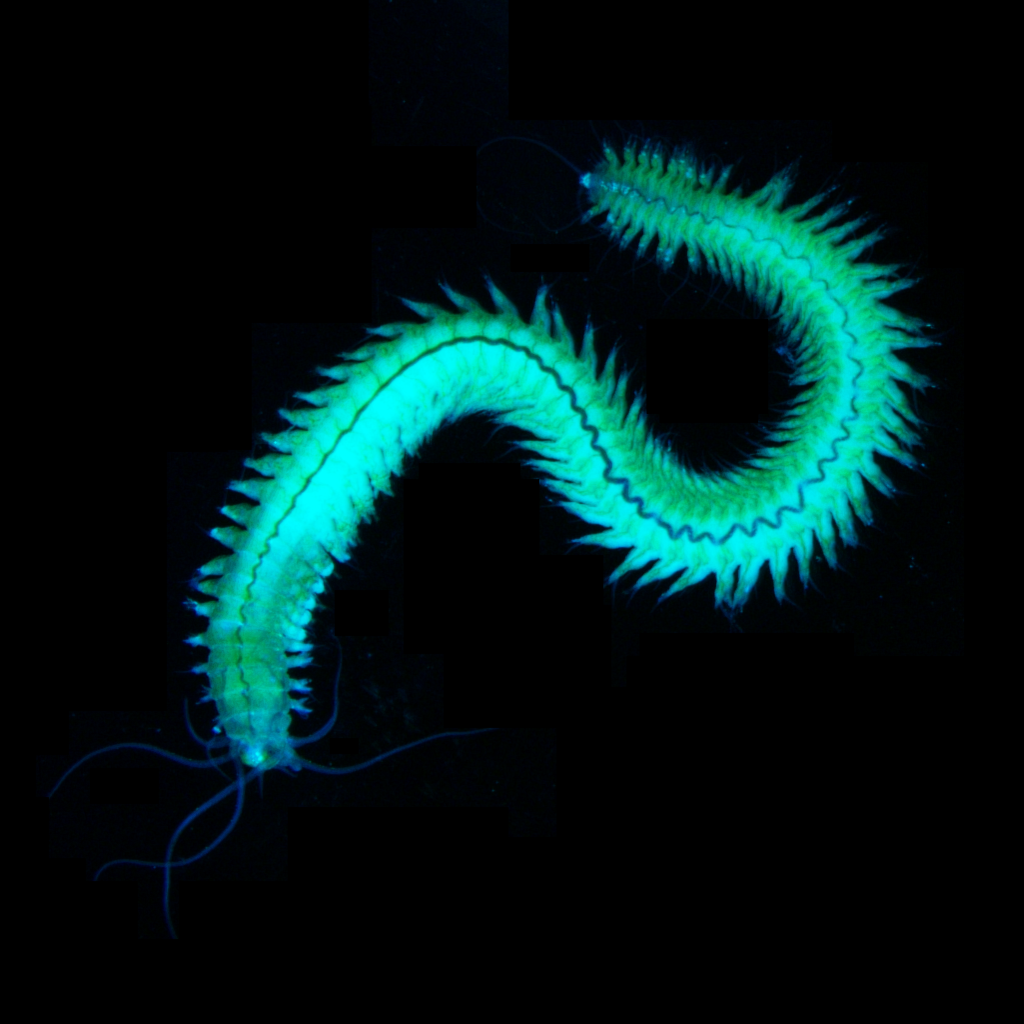

In [25]:
# Zero the red channel (matches prior CLI helper)
remove_red_channel(
    photo="../Pd.tif",
    output="../Pd_BG.jpg",
    quality=95
)


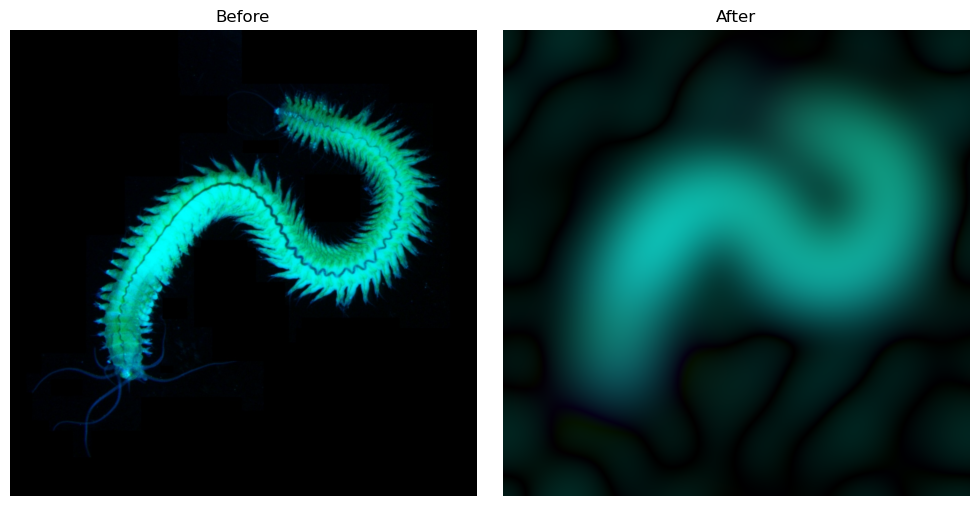

array([[[ 0, 27, 22],
        [ 0, 27, 22],
        [ 0, 26, 22],
        ...,
        [ 0, 27, 23],
        [ 0, 27, 23],
        [ 0, 27, 23]],

       [[ 0, 27, 23],
        [ 0, 27, 22],
        [ 0, 27, 22],
        ...,
        [ 0, 27, 23],
        [ 0, 27, 23],
        [ 0, 27, 23]],

       [[ 0, 27, 23],
        [ 0, 27, 23],
        [ 0, 27, 23],
        ...,
        [ 0, 28, 23],
        [ 0, 28, 23],
        [ 0, 27, 23]],

       ...,

       [[ 0, 26, 22],
        [ 0, 26, 22],
        [ 0, 26, 21],
        ...,
        [ 0, 27, 22],
        [ 0, 26, 22],
        [ 0, 26, 22]],

       [[ 0, 26, 22],
        [ 0, 26, 22],
        [ 0, 26, 22],
        ...,
        [ 0, 27, 22],
        [ 0, 27, 22],
        [ 0, 26, 22]],

       [[ 0, 27, 22],
        [ 0, 26, 22],
        [ 0, 26, 22],
        ...,
        [ 0, 27, 23],
        [ 0, 27, 22],
        [ 0, 27, 22]]], dtype=uint8)

In [26]:
# Must be square & power-of-two (e.g., 1024x1024 RGB). If not, resize or crop first.
sharpness_glimpse(
    photo="../Pd13.3_BG.jpg",
    distance=3,
    real_width=3,
    eye_resolution_x= 7,
    eye_resolution_y=None,   # defaults to X if None
    plot=True,
    output="../Pd_filtered_7deg.jpg"
)


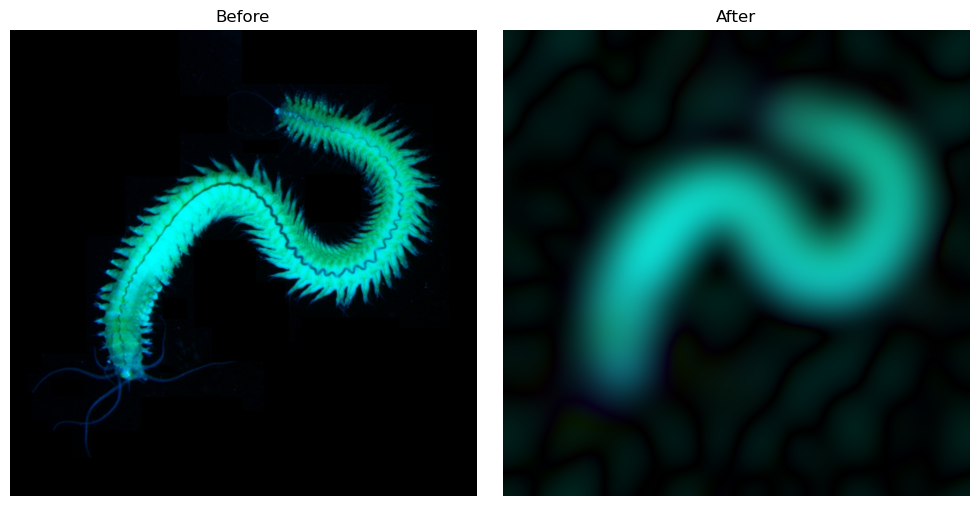

array([[[ 0, 26, 22],
        [ 0, 26, 22],
        [ 0, 25, 22],
        ...,
        [ 0, 26, 22],
        [ 0, 26, 22],
        [ 0, 26, 22]],

       [[ 0, 26, 22],
        [ 0, 26, 22],
        [ 0, 26, 22],
        ...,
        [ 0, 26, 22],
        [ 0, 26, 22],
        [ 0, 26, 22]],

       [[ 0, 26, 22],
        [ 0, 26, 22],
        [ 0, 26, 22],
        ...,
        [ 0, 26, 22],
        [ 0, 26, 22],
        [ 0, 26, 22]],

       ...,

       [[ 0, 25, 21],
        [ 0, 25, 21],
        [ 0, 25, 21],
        ...,
        [ 0, 25, 21],
        [ 0, 25, 21],
        [ 0, 25, 21]],

       [[ 0, 25, 21],
        [ 0, 25, 21],
        [ 0, 25, 21],
        ...,
        [ 0, 25, 21],
        [ 0, 25, 21],
        [ 0, 25, 21]],

       [[ 0, 25, 22],
        [ 0, 25, 22],
        [ 0, 25, 22],
        ...,
        [ 0, 25, 22],
        [ 0, 25, 22],
        [ 0, 25, 22]]], dtype=uint8)

In [27]:
# Must be square & power-of-two (e.g., 1024x1024 RGB). If not, resize or crop first.
sharpness_glimpse(
    photo="../Pd13.3_BG.jpg",
    distance=3,
    real_width=3,
    eye_resolution_x= 4.3,
    eye_resolution_y=None,   # defaults to X if None
    plot=True,
    output="../Pd_filtered_4_3_deg.jpg"
)


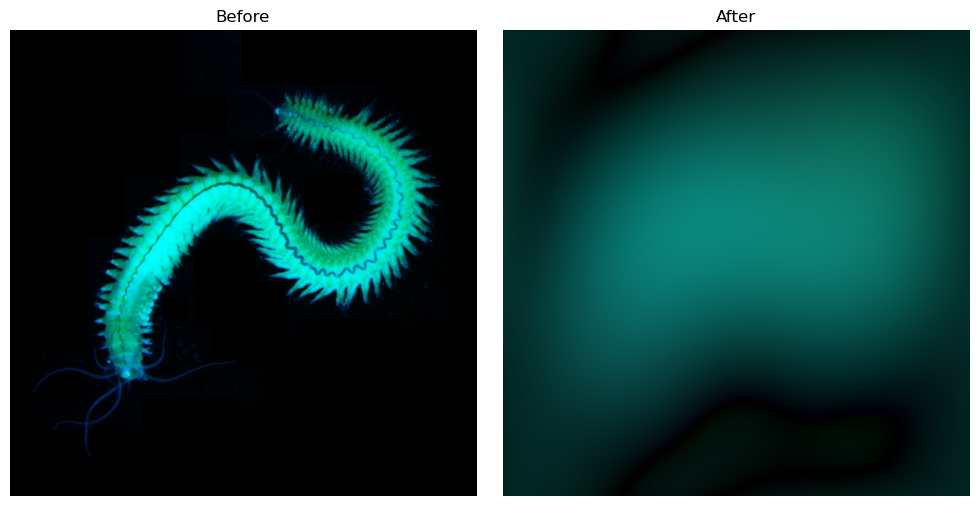

array([[[ 1, 36, 33],
        [ 1, 36, 33],
        [ 1, 36, 33],
        ...,
        [ 1, 36, 33],
        [ 1, 36, 33],
        [ 1, 36, 33]],

       [[ 1, 36, 33],
        [ 1, 36, 33],
        [ 1, 36, 33],
        ...,
        [ 1, 36, 33],
        [ 1, 36, 33],
        [ 1, 36, 33]],

       [[ 1, 36, 33],
        [ 1, 36, 33],
        [ 1, 36, 33],
        ...,
        [ 1, 36, 33],
        [ 1, 36, 33],
        [ 1, 36, 33]],

       ...,

       [[ 1, 36, 33],
        [ 1, 36, 33],
        [ 1, 36, 33],
        ...,
        [ 1, 36, 33],
        [ 1, 36, 33],
        [ 1, 36, 33]],

       [[ 1, 36, 33],
        [ 1, 36, 33],
        [ 1, 36, 33],
        ...,
        [ 1, 36, 33],
        [ 1, 36, 33],
        [ 1, 36, 33]],

       [[ 1, 36, 33],
        [ 1, 36, 33],
        [ 1, 36, 33],
        ...,
        [ 1, 36, 33],
        [ 1, 36, 33],
        [ 1, 36, 33]]], dtype=uint8)

In [28]:
# Must be square & power-of-two (e.g., 1024x1024 RGB). If not, resize or crop first.
sharpness_glimpse(
    photo="../Pd13.3_BG.jpg",
    distance=3,
    real_width=3,
    eye_resolution_x= 16.2,
    eye_resolution_y=None,   # defaults to X if None
    plot=True,
    output="../Pd_filtered_16_2_deg.jpg"
)


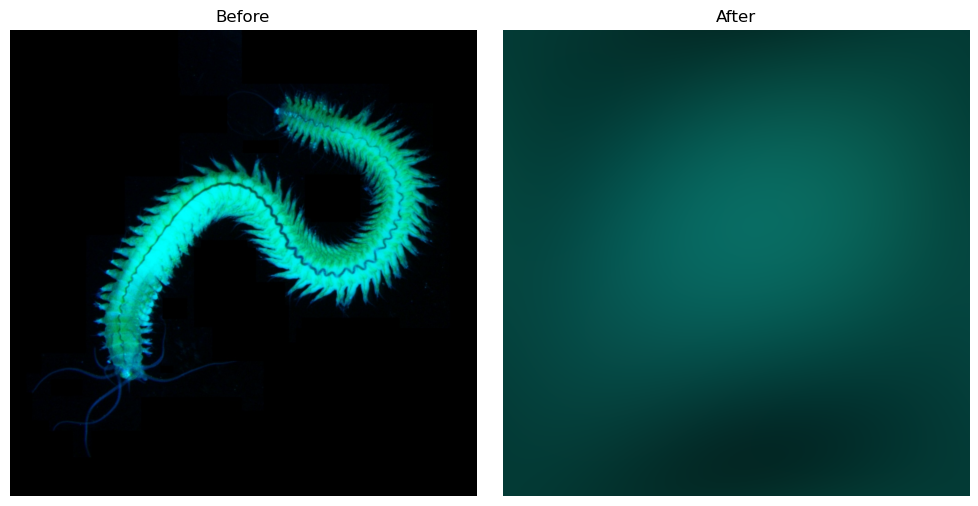

array([[[ 3, 58, 53],
        [ 3, 58, 53],
        [ 3, 58, 53],
        ...,
        [ 3, 58, 53],
        [ 3, 58, 53],
        [ 3, 58, 53]],

       [[ 3, 58, 53],
        [ 3, 58, 53],
        [ 3, 58, 53],
        ...,
        [ 3, 58, 53],
        [ 3, 58, 53],
        [ 3, 58, 53]],

       [[ 3, 58, 53],
        [ 3, 58, 53],
        [ 3, 58, 53],
        ...,
        [ 3, 58, 53],
        [ 3, 58, 53],
        [ 3, 58, 53]],

       ...,

       [[ 3, 58, 53],
        [ 3, 58, 53],
        [ 3, 58, 53],
        ...,
        [ 3, 58, 53],
        [ 3, 58, 53],
        [ 3, 58, 53]],

       [[ 3, 58, 53],
        [ 3, 58, 53],
        [ 3, 58, 53],
        ...,
        [ 3, 58, 53],
        [ 3, 58, 53],
        [ 3, 58, 53]],

       [[ 3, 58, 53],
        [ 3, 58, 53],
        [ 3, 58, 53],
        ...,
        [ 3, 58, 53],
        [ 3, 58, 53],
        [ 3, 58, 53]]], dtype=uint8)

In [29]:
# Must be square & power-of-two (e.g., 1024x1024 RGB). If not, resize or crop first.
sharpness_glimpse(
    photo="../Pd13.3_BG.jpg",
    distance=3,
    real_width=3,
    eye_resolution_x= 28.9,
    eye_resolution_y=None,   # defaults to X if None
    plot=True,
    output="../Pd_filtered_28_9_deg.jpg"
)


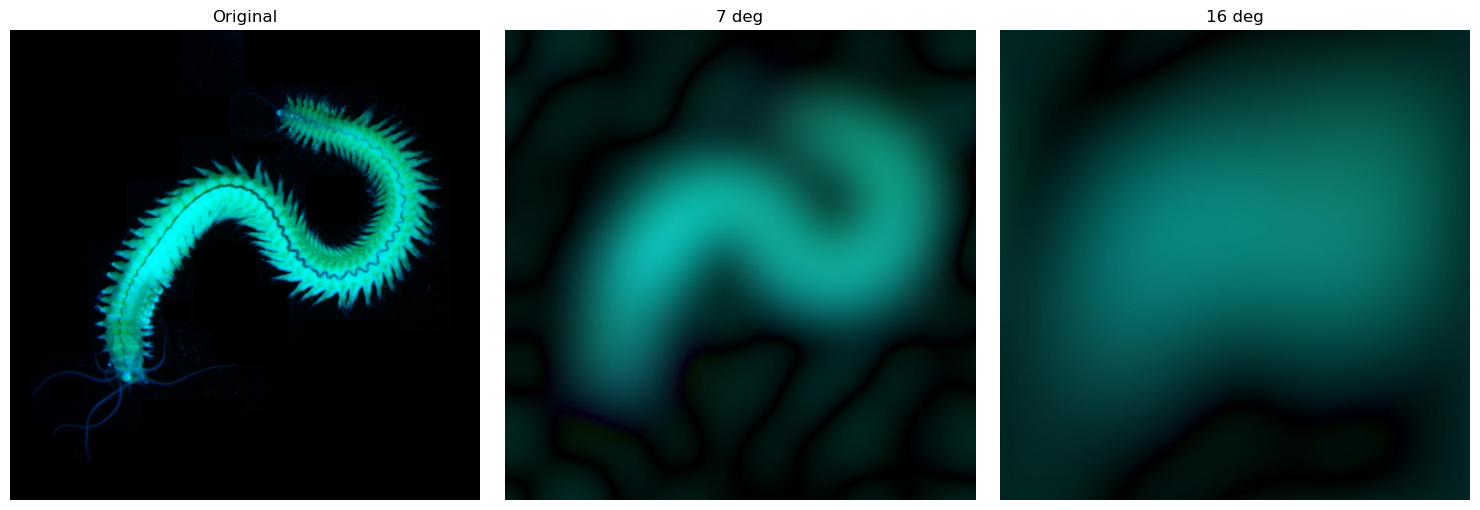

In [1]:
# Compare original and filtered views
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
panels = [
    ("Original", "../Pd_BG.jpg"),
    ("7 deg", "../Pd_filtered_7deg.jpg"),
    ("16 deg", "../Pd_filtered_16_2_deg.jpg"),
]
for ax, (title, path) in zip(axes, panels):
    ax.imshow(mpimg.imread(path))
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()
